In [1]:
import numpy as np
import matplotlib.pyplot as plt

class MLP_Network:
    def __init__(self, input_size=1, hidden_size=2, output_size=1, eta=0.3, epsilon=1e-3):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.eta = eta  # Коэффициент обучения
        self.epsilon = epsilon  # Порог ошибки
        
        # Инициализация весов
        self.W_hidden = np.random.uniform(0, 0.9, (hidden_size, input_size))  # Вход -> скрытый слой
        self.b_hidden = np.zeros(hidden_size)  # Смещение скрытого слоя
        self.W_output = np.random.uniform(0, 0.9, (output_size, hidden_size))  # Скрытый -> выход
        self.b_output = np.zeros(output_size)  # Смещение выходного слоя
    
    def activation(self, x):
        """Гиперболический тангенс"""
        return (1 - np.exp(-x)) / (1 + np.exp(-x))
    
    def activation_derivative(self, x):
        """Производная tanh через функцию"""
        return 0.5 * (1 - self.activation(x) ** 2)
    
    def forward(self, x):
        """Прямое распространение"""
        self.net_hidden = np.dot(self.W_hidden, x) + self.b_hidden
        self.out_hidden = self.activation(self.net_hidden)
        self.net_output = np.dot(self.W_output, self.out_hidden) + self.b_output
        self.out_output = self.activation(self.net_output)
        return self.out_output
    
    def backward(self, x, target):
        """Обратное распространение ошибки"""
        output_error = target - self.out_output  # Ошибка на выходе
        output_delta = output_error * self.activation_derivative(self.net_output)
        
        hidden_error = np.dot(self.W_output.T, output_delta)
        hidden_delta = hidden_error * self.activation_derivative(self.net_hidden)
        
        # Обновление весов
        self.W_output += self.eta * np.outer(output_delta, self.out_hidden)
        self.b_output += self.eta * output_delta
        self.W_hidden += self.eta * np.outer(hidden_delta, x)
        self.b_hidden += self.eta * hidden_delta
        
        return np.sqrt(np.mean(output_error ** 2))  # Среднеквадратичная ошибка
    
    def train(self, inputs, targets, max_epochs=1000):
        print("Epoch # | Target t | Output y | Error E(k) | Hidden Weights | Output Weights")
        error_history = []
        for epoch in range(1, max_epochs + 1):
            total_error = 0
            for x, target in zip(inputs, targets):
                self.forward(x)
                error = self.backward(x, target)
                total_error += error**2
            
            avg_error = np.sqrt(total_error / len(inputs))  # Среднеквадратичная ошибка
            error_history.append(avg_error)
            
            # Вывод строки таблицы
            print(f"{epoch:6d} | {target[0]:9.4f} | {self.out_output[0]:8.4f} | {avg_error:10.6f} | {self.W_hidden.flatten()} | {self.W_output.flatten()}")
            
            if avg_error <= self.epsilon:
                break
        return error_history

Epoch # | Target t | Output y | Error E(k) | Hidden Weights | Output Weights
     1 |   -0.3000 |   0.1757 |   0.450356 | [0.68404332 0.16574331] | [0.6167286  0.09503592]
     2 |   -0.3000 |   0.0871 |   0.361918 | [0.64670055 0.15825688] | [0.5681437  0.08199783]
     3 |   -0.3000 |   0.0162 |   0.291479 | [0.61761464 0.15297316] | [0.53129257 0.07205351]
     4 |   -0.3000 |  -0.0397 |   0.236245 | [0.59488587 0.14918561] | [0.50308843 0.06435498]
     5 |   -0.3000 |  -0.0837 |   0.192968 | [0.57696085 0.14641702] | [0.48120103 0.05829622]
     6 |   -0.3000 |  -0.1185 |   0.158860 | [0.56266653 0.14435254] | [0.46396028 0.05345339]
     7 |   -0.3000 |  -0.1464 |   0.131762 | [0.55114002 0.14278387] | [0.45018392 0.04952869]
     8 |   -0.3000 |  -0.1689 |   0.110061 | [0.54174833 0.14157129] | [0.43903061 0.04630959]
     9 |   -0.3000 |  -0.1871 |   0.092562 | [0.53402366 0.14061936] | [0.42989384 0.0436415 ]
    10 |   -0.3000 |  -0.2021 |   0.078376 | [0.52761611 0.13986159]

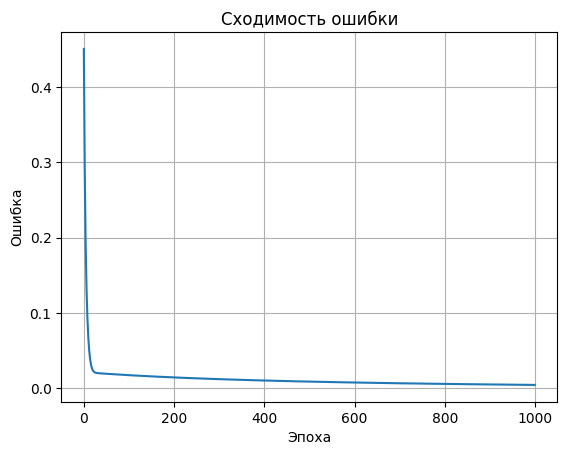

In [2]:
# Тестовые данные
inputs = np.array([[1], [2]])
targets = np.array([[-0.3], [-0.3]])

mlp = MLP_Network()
error_history = mlp.train(inputs, targets, max_epochs=1000)

# График ошибки
plt.plot(error_history)
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Сходимость ошибки")
plt.grid()
plt.show()